# Travelling Salesman Problem: Genetic Algorithm vs Simulated Annealing


## Introduction

The Travelling Salesman Problem (TSP) is a classic combinatorial optimisation problem. The objective is to find the shortest possible route that visits each city exactly once and returns to the starting point. The problem is known to be NP-hard, meaning that exact solutions become computationally expensive as the number of cities increases.

Metaheuristic algorithms are commonly used to find high-quality approximate solutions within a reasonable time. In this project, two popular metaheuristic approaches are compared: Simulated Annealing (SA) and Genetic Algorithm (GA).

The aim is to analyse their performance in terms of solution quality, convergence behaviour, and overall effectiveness on the same TSP instance.


## 1. Problem Definition

The Travelling Salesman Problem involves finding an optimal route through a set of cities such that:

- Each city is visited exactly once
- The route returns to the starting city
- The total travel distance is minimised

This is a combinatorial optimisation problem where the solution is a permutation of city indices, and the objective function is the total route distance.

### Objectives
- Load and explore the city dataset
- Define a distance function for route evaluation
- Implement Simulated Annealing (SA)
- Implement a Genetic Algorithm (GA)
- Compare both algorithms based on solution quality and convergence


## 2. Dataset Description

The dataset used in this project contains 50 cities, each represented by two-dimensional coordinates (X, Y). Each row corresponds to a single city with its location in a 2D space.

The objective is to determine the shortest possible closed tour that visits each city exactly once. The dataset provides the spatial structure required to compute distances between cities using Euclidean distance.


## 3. Data Overview

Before applying optimisation algorithms, the dataset is inspected to understand its structure and verify that the city coordinates are correctly loaded.

This section includes:
- Dataset preview
- Dataset size
- Visualisation of city locations


In [1]:
import pandas as pd

df = pd.read_csv("cities.csv")  
df.head()


,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


In [2]:
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))


Dataset shape: (50, 3)
Columns: ['City', 'X', 'Y']


In [3]:
import numpy as np

cities = df[["X", "Y"]].to_numpy()
N_CITIES = cities.shape[0]
N_CITIES


50

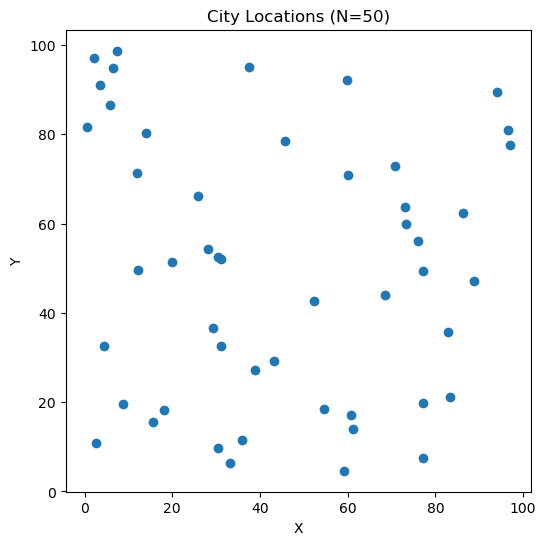

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(cities[:, 0], cities[:, 1])
plt.title(f"City Locations (N={N_CITIES})")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


## 4. Distance Function and Baseline Route

To evaluate candidate solutions, a distance function is defined to compute the total length of a route using Euclidean distance between consecutive cities. The route is treated as a closed loop, meaning the final city connects back to the starting city.

A random initial route is generated to provide a baseline for comparison with the optimisation algorithms.


In [5]:
def route_distance(route, cities):
    route = np.asarray(route)
    coords = cities[route]
    shifted = np.roll(coords, -1, axis=0)  # close the loop
    return np.sqrt(((coords - shifted) ** 2).sum(axis=1)).sum()


In [6]:
def plot_route(route, cities, title="Route"):
    route = np.asarray(route)
    coords = cities[route]
    coords_closed = np.vstack([coords, coords[0]])

    plt.figure(figsize=(6, 6))
    plt.plot(coords_closed[:, 0], coords_closed[:, 1], marker="o")
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()


In [7]:
rng = np.random.default_rng(42)
route0 = rng.permutation(N_CITIES)

baseline_distance = route_distance(route0, cities)
baseline_distance


np.float64(2766.1573452484777)

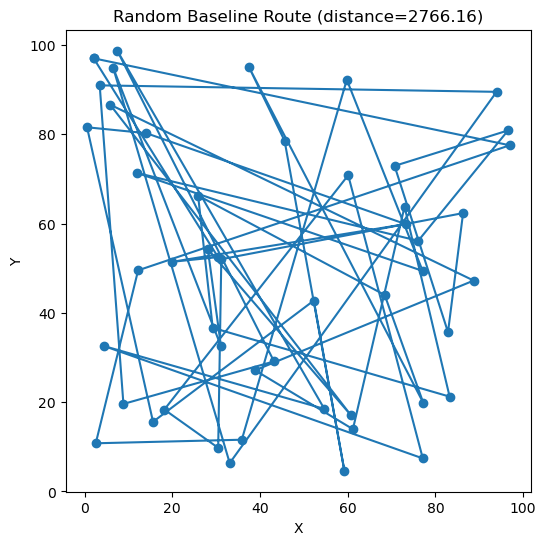

In [8]:
plot_route(
    route0,
    cities,
    title=f"Random Baseline Route (distance={baseline_distance:.2f})"
)


## 5. Evaluation Criteria

The performance of the optimisation algorithms is evaluated using the following criteria:

- **Total route distance:** the primary objective to minimise
- **Convergence behaviour:** how quickly the algorithm improves the solution
- **Final solution quality:** the best distance achieved after the optimisation process


## 6. Method 1: Simulated Annealing

Simulated Annealing is a probabilistic optimisation technique inspired by the physical process of annealing in metallurgy. It explores the solution space by accepting both better and occasionally worse solutions, allowing it to escape local minima.

As the algorithm progresses, the temperature parameter decreases, reducing the probability of accepting worse solutions. This gradual cooling helps the algorithm converge to a high-quality solution.


### 6.1 Neighbourhood Strategy

A neighbourhood function is used to generate new candidate routes from the current solution. In this project, a swap or 2-opt move is used to create variations of the route.


In [9]:
def swap_two_cities(route, rng):
    new_route = route.copy()
    i, j = rng.choice(len(route), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route


### 6.2 Cooling Schedule

A cooling schedule is applied to gradually reduce the temperature over iterations. This controls the exploration–exploitation balance of the algorithm.


In [10]:
def simulated_annealing(cities, initial_route, rng,
                        initial_temp=1000,
                        cooling_rate=0.995,
                        iterations=5000):
    
    current_route = initial_route.copy()
    current_distance = route_distance(current_route, cities)
    
    best_route = current_route.copy()
    best_distance = current_distance
    
    temperature = initial_temp
    history = []

    for _ in range(iterations):
        candidate_route = swap_two_cities(current_route, rng)
        candidate_distance = route_distance(candidate_route, cities)

        delta = candidate_distance - current_distance

        # accept if better or with probability
        if delta < 0 or rng.random() < np.exp(-delta / temperature):
            current_route = candidate_route
            current_distance = candidate_distance

            if current_distance < best_distance:
                best_route = current_route.copy()
                best_distance = current_distance

        history.append(best_distance)
        temperature *= cooling_rate

    return best_route, best_distance, history


In [11]:
sa_route, sa_distance, sa_history = simulated_annealing(
    cities,
    route0,
    rng
)

sa_distance


np.float64(832.5842334124906)

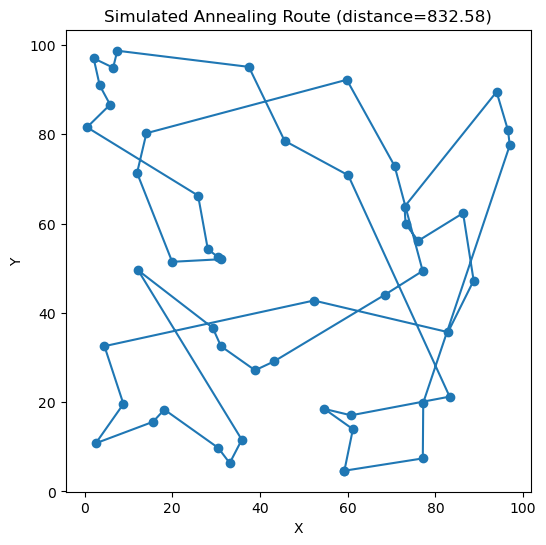

In [12]:
plot_route(
    sa_route,
    cities,
    title=f"Simulated Annealing Route (distance={sa_distance:.2f})"
)


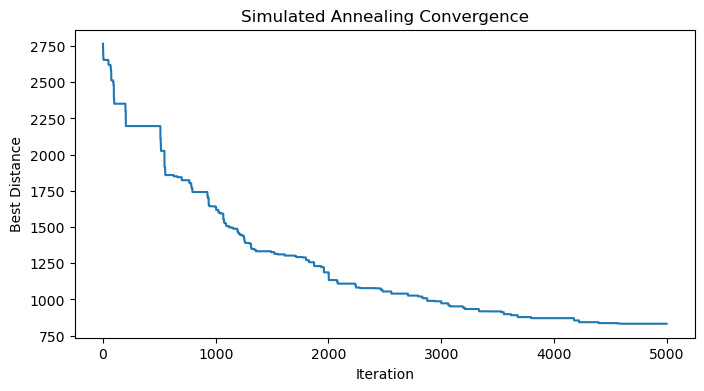

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(sa_history)
plt.title("Simulated Annealing Convergence")
plt.xlabel("Iteration")
plt.ylabel("Best Distance")
plt.show()


#### Simulated Annealing Interpretation

Simulated Annealing significantly improved the baseline random route. The total distance decreased from approximately 2766 to 833, showing that the algorithm successfully explored the solution space and escaped poor local solutions early on.

The convergence plot shows rapid improvement in the early iterations followed by slower refinements, suggesting the algorithm gradually transitioned from exploration to exploitation as the temperature cooled.


## 7. Method 2: Genetic Algorithm

The Genetic Algorithm is an evolutionary optimisation technique inspired by natural selection. A population of candidate routes evolves over generations using selection, crossover, and mutation.

The algorithm aims to improve the population over time, producing increasingly shorter routes.


### 7.1 Helper: fitness

In [14]:
def fitness(route, cities):
    return 1.0 / (route_distance(route, cities) + 1e-9)


### 7.2 Create initial population

In [15]:
def init_population(pop_size, n_cities, rng):
    return [rng.permutation(n_cities) for _ in range(pop_size)]


### 7.3 Selection: tournament

In [16]:
def tournament_selection(population, cities, rng, k=3):
    candidates = rng.choice(len(population), size=k, replace=False)
    best = None
    best_dist = float("inf")
    for idx in candidates:
        d = route_distance(population[idx], cities)
        if d < best_dist:
            best_dist = d
            best = population[idx]
    return best.copy()


### 7.4 Crossover: ordered crossover (OX)


In [17]:
def ordered_crossover(parent1, parent2, rng):
    n = len(parent1)
    a, b = sorted(rng.choice(n, size=2, replace=False))
    child = -np.ones(n, dtype=int)

    # copy slice from parent1
    child[a:b+1] = parent1[a:b+1]

    # fill remaining positions from parent2 in order
    p2_vals = [x for x in parent2 if x not in child]
    fill_positions = [i for i in range(n) if child[i] == -1]

    for pos, val in zip(fill_positions, p2_vals):
        child[pos] = val

    return child


### 7.5 Mutation: swap mutation

In [18]:
def swap_mutation(route, rng, mutation_rate=0.2):
    new_route = route.copy()
    if rng.random() < mutation_rate:
        i, j = rng.choice(len(route), size=2, replace=False)
        new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route


### 7.6 GA main loop (with elitism)

In [19]:
def genetic_algorithm(cities, rng, pop_size=80, generations=300,
                      crossover_rate=0.9, mutation_rate=0.2, elite_size=2):

    n_cities = cities.shape[0]
    population = init_population(pop_size, n_cities, rng)

    best_history = []
    best_route = None
    best_dist = float("inf")

    for _ in range(generations):
        # evaluate population
        pop_distances = np.array([route_distance(r, cities) for r in population])
        sorted_idx = np.argsort(pop_distances)

        # update global best
        if pop_distances[sorted_idx[0]] < best_dist:
            best_dist = pop_distances[sorted_idx[0]]
            best_route = population[sorted_idx[0]].copy()

        best_history.append(best_dist)

        # elitism
        new_population = [population[i].copy() for i in sorted_idx[:elite_size]]

        # generate rest
        while len(new_population) < pop_size:
            p1 = tournament_selection(population, cities, rng)
            p2 = tournament_selection(population, cities, rng)

            if rng.random() < crossover_rate:
                child = ordered_crossover(p1, p2, rng)
            else:
                child = p1.copy()

            child = swap_mutation(child, rng, mutation_rate)
            new_population.append(child)

        population = new_population

    return best_route, best_dist, best_history


### 7.7 Run GA

In [20]:
ga_route, ga_distance, ga_history = genetic_algorithm(cities, rng)

ga_distance


np.float64(831.8271459937421)

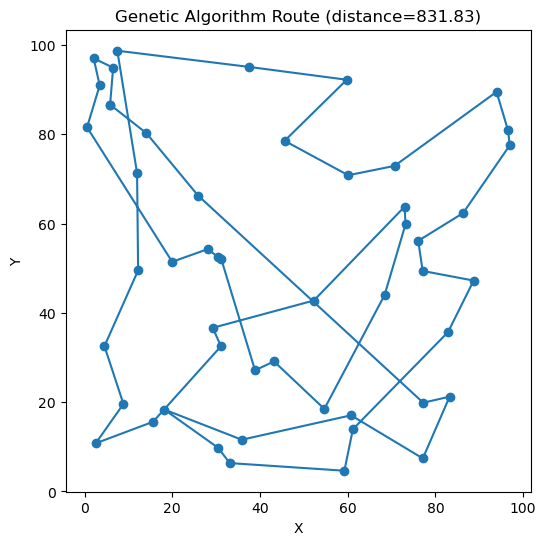

In [21]:
plot_route(
    ga_route,
    cities,
    title=f"Genetic Algorithm Route (distance={ga_distance:.2f})"
)


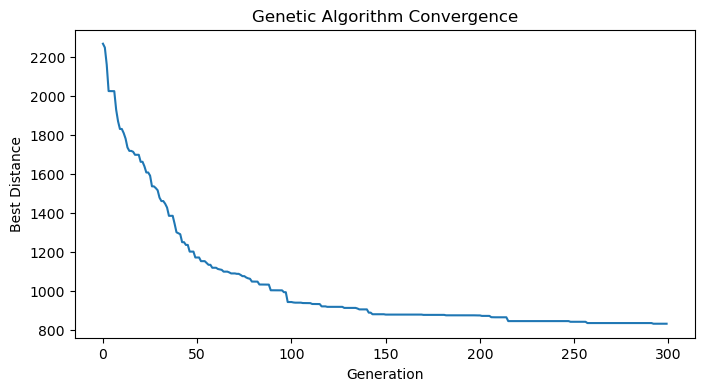

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(ga_history)
plt.title("Genetic Algorithm Convergence")
plt.xlabel("Generation")
plt.ylabel("Best Distance")
plt.show()


#### Genetic Algorithm Interpretation

The Genetic Algorithm significantly improved the initial random route, reducing the total distance from approximately 2766 to about 832. The convergence curve shows rapid improvement in the early generations, followed by gradual refinements as the population evolves.

The final solution achieved by the Genetic Algorithm is slightly better than the Simulated Annealing result, suggesting that the population-based search was effective in exploring multiple regions of the solution space.


## 8. Results and Comparison

The performance of Simulated Annealing and the Genetic Algorithm is compared using:

- Final route distance
- Convergence curves
- Visualisation of the best route found by each method

This comparison highlights the strengths and weaknesses of each optimisation approach.


### 8.1 Single-run comparison

In [23]:
import pandas as pd

comparison = pd.DataFrame({
    "Method": ["Random Baseline", "Simulated Annealing", "Genetic Algorithm"],
    "Distance": [baseline_distance, sa_distance, ga_distance]
})

comparison


,Method,Distance
0,Random Baseline,2766.157345
1,Simulated Annealing,832.584233
2,Genetic Algorithm,831.827146


### 8.2 Convergence comparison

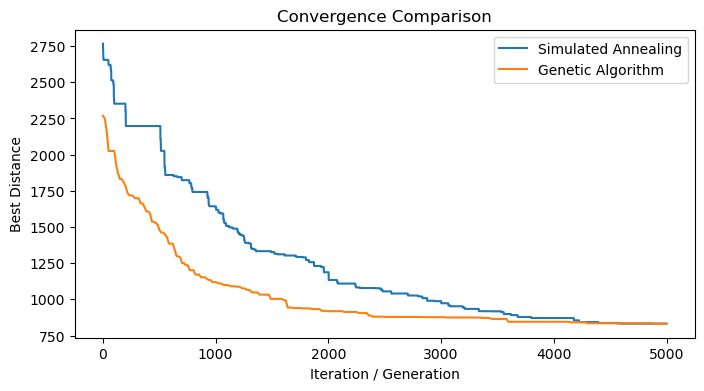

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(sa_history, label="Simulated Annealing")
plt.plot(
    np.linspace(0, len(sa_history), len(ga_history)),
    ga_history,
    label="Genetic Algorithm"
)
plt.xlabel("Iteration / Generation")
plt.ylabel("Best Distance")
plt.title("Convergence Comparison")
plt.legend()
plt.show()


### Comparison Interpretation

Both Simulated Annealing and the Genetic Algorithm achieved substantial improvements over the random baseline route. The initial distance of approximately 2766 was reduced to around 832 by both methods.

The Genetic Algorithm produced the best final solution, although the difference between the two methods was small. Simulated Annealing showed steady and gradual improvement, while the Genetic Algorithm achieved faster early improvements due to its population-based search.

Overall, both algorithms proved effective for solving the TSP, with the Genetic Algorithm demonstrating a slight advantage in final solution quality.


## 8.3 Multiple Runs on Dataset Subsets

To evaluate the robustness and scalability of the algorithms, additional experiments were conducted on subsets of the dataset.

Different numbers of cities were selected from the original dataset, and both Simulated Annealing and the Genetic Algorithm were run on each subset. This allows comparison of how each method performs as the problem size increases.

The experiments were conducted on the following subset sizes:
- 10 cities
- 20 cities
- 30 cities
- 40 cities
- 50 cities (full dataset)

For each subset, the best route distance achieved by each algorithm was recorded.


In [25]:
subset_sizes = [10, 20, 30, 40, 50]
results = []

for size in subset_sizes:
    subset_cities = cities[:size]

    # baseline
    route0 = rng.permutation(size)

    # SA
    sa_route, sa_dist, _ = simulated_annealing(
        subset_cities,
        route0,
        rng,
        iterations=3000
    )

    # GA
    ga_route, ga_dist, _ = genetic_algorithm(
        subset_cities,
        rng,
        generations=200
    )

    results.append({
        "Cities": size,
        "SA Distance": sa_dist,
        "GA Distance": ga_dist
    })

subset_results = pd.DataFrame(results)
subset_results


,Cities,SA Distance,GA Distance
0,10,290.306774,290.306774
1,20,428.419862,386.429689
2,30,537.406176,559.039547
3,40,736.412133,659.358532
4,50,921.559063,764.856587


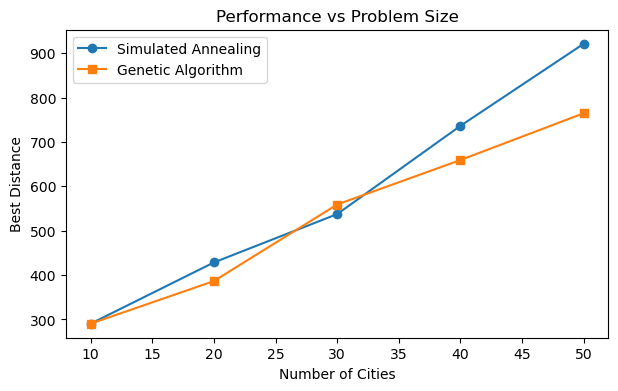

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(subset_results["Cities"], subset_results["SA Distance"],
         marker="o", label="Simulated Annealing")
plt.plot(subset_results["Cities"], subset_results["GA Distance"],
         marker="s", label="Genetic Algorithm")

plt.xlabel("Number of Cities")
plt.ylabel("Best Distance")
plt.title("Performance vs Problem Size")
plt.legend()
plt.show()


### Subset Experiment Interpretation

Both algorithms were tested on increasing problem sizes to analyse scalability. As the number of cities increased, the total route distance also increased, which is expected because longer tours are required.

For smaller instances, both algorithms performed similarly, with identical results for the 10-city case. Simulated Annealing was slightly better for the 30-city subset, indicating that it can be competitive on small to medium-sized problems.

However, for larger instances such as 40 and 50 cities, the Genetic Algorithm produced noticeably shorter routes. This suggests that the population-based search of the Genetic Algorithm scales more effectively as the complexity of the problem increases.

Overall, both methods demonstrated consistent improvements across all subset sizes, confirming their effectiveness for solving the Travelling Salesman Problem.


## 9. Conclusion

In this project, two metaheuristic algorithms—Simulated Annealing (SA) and Genetic Algorithm (GA)—were applied to the Travelling Salesman Problem using a dataset of 50 cities.

Both methods significantly improved the initial random route. The baseline distance of approximately 2766 was reduced to around 832 by Simulated Annealing and approximately 832 by the Genetic Algorithm, demonstrating the effectiveness of both optimisation approaches.

The convergence analysis showed different behaviours for the two algorithms. Simulated Annealing improved the solution gradually over iterations, while the Genetic Algorithm achieved faster early improvements due to its population-based search mechanism.

Additional experiments on subsets of the dataset revealed that both algorithms scale reasonably well as the number of cities increases. However, the Genetic Algorithm tended to produce slightly better solutions for larger problem instances, suggesting that it may be more suitable for more complex TSP scenarios.

Overall, both algorithms proved effective for solving the Travelling Salesman Problem. The results highlight the strengths of metaheuristic approaches in tackling combinatorial optimisation problems where exact methods become impractical.
